# Assignment 3 — Revealing representative traffic day-types

### Goal
Use the 2021 highway traffic data to discover representative **day-types** and decide which clustering method and number of clusters best represent the traffic patterns.

Compare:
- **K-means**
- **Agglomerative clustering**
- **DBSCAN**
- **Gaussian Mixture Model (GMM)**

Evaluate the clusterings using:
1. **Internal metrics** — Silhouette, Calinski–Harabasz and Davies–Bouldin.
2. **External evaluation** — a simple centroid-based short-term prediction task on the supplied evaluation dataset.
3. **Expert interpretation** — looking at the calendar and cluster-centroid traffic profiles.

### Track used
**Simpler track:** the supplied evaluation dataset is used directly for external evaluation. We do not create a separate test subset from the 2021 training data.

### Import libraries needed

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error
)

## 1. Load Dataset

In [4]:
# Import df
train_df = "dataset_exercise_5_clustering_highway_traffic.csv"
eval_df = "evaluation_dataset_exercise_5_clustering_highway_traffic.csv"

data_df = pd.read_csv(train_df, sep=";")
data_eval_df = pd.read_csv(eval_df, sep=";")

print("Training data shape:", data_df.shape)
print("Evaluation data shape:", data_eval_df.shape)

data_df.head()

Training data shape: (104843, 7)
Evaluation data shape: (22944, 7)


,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52


## 2. Convert the raw observations into daily data vector

In [6]:
# Sort the data chronologically and by interval
data_df = data_df.sort_values(["Date", "Interval_5"])

# Extract the unique days and calculate the tot number of unique days - i.e. how many profile we need
days = np.unique(data_df["Date"].values)
ndays = len(days)

# Group df observations by day
day_subsets_df = data_df.groupby("Date")

# Define the tot n of 5-min interval in a day: 288 five-minute intervals
nintvals = 288

# Create the day × time empty matrix filled with Nas 
vectorized_day_dataset = np.zeros((ndays, nintvals))
vectorized_day_dataset.fill(np.nan)

# Loop by putting every traffic flow observation into its correct day and time interval
for i in range(0, ndays):
    # Get the DataFrame corresponding to the current day
    df_t = day_subsets_df.get_group(days[i])

    # Loop through each row in the current day's DataFrame
    for j in range(len(df_t)):
        # Get the current day's DataFrame
        df_t = day_subsets_df.get_group(days[i])

        # Extract the "Interval_5" and "flow" values and populate 'vectorized_day_dataset'
        vectorized_day_dataset[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

print("Number of days:", ndays)
print("Shape of day matrix:", vectorized_day_dataset.shape)
print(vectorized_day_dataset)

Number of days: 365
Shape of day matrix: (365, 288)
[[ 39.  18.  26. ...  32.  39.  34.]
 [ 30.  32.  27. ...  44.  41.  39.]
 [ 36.  44.  52. ...  50.  45.  23.]
 ...
 [ 20.  34.  31. ...  38.  42.  36.]
 [ 36.  40.  25. ...  38.  56.  35.]
 [ 33.  32.  34. ... 130. 129. 117.]]


## 3. Check missing observations

Why? Because K-means, Agglomerative clustering and GMM cannot work directly with `NaN` values. So, if there are Nan values removed the days containig them.


In [35]:
nans_per_day = np.sum(np.isnan(vectorized_day_dataset), axis=1)

print("Total missing observations:", np.sum(np.isnan(vectorized_day_dataset)))
print("Days with at least one missing value:", np.sum(nans_per_day > 0))

# Keep only complete days
complete_indices = np.where(nans_per_day == 0)[0]

X_days = vectorized_day_dataset[complete_indices, :]
days_complete = days[complete_indices]

print("Clustering matrix shape:", X_days.shape)
print('rate of nans',np.sum(np.isnan(vectorized_day_dataset))/(ndays*nintvals)) # 0.28% of df

nans_per_time = np.sum(np.isnan(vectorized_day_dataset),0)
print(nans_per_time.shape)


Total missing observations: 277
Days with at least one missing value: 28
Clustering matrix shape: (337, 288)
rate of nans 0.0026350837138508373
(288,)


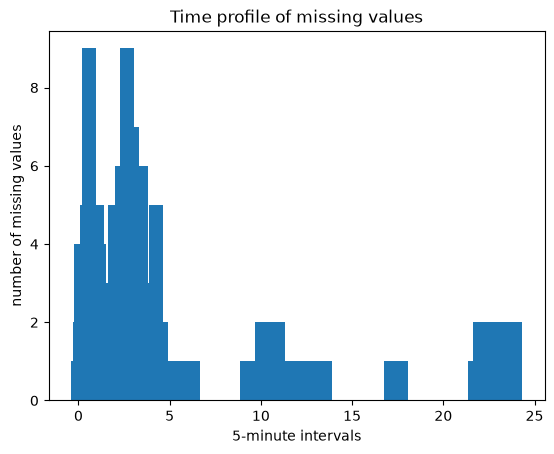

In [36]:
nans_per_time = np.sum(np.isnan(vectorized_day_dataset),0)
fig, ax = plt.subplots()
# Create an array 'x_axis' representing the 5-minute intervals
x_axis = np.arange(0, nintvals, 1, dtype=int)
# Initialize an empty list 'x_axis_hours' to store time values in hours
x_axis_hours = []
# Convert interval indices to hours and append them to 'x_axis_hours'
for i in range(0, len(x_axis)):
  x_axis_hours.append(float(x_axis[i]*5)/60)
ax.bar(x_axis_hours,height=nans_per_time)


ax.set_ylabel('number of missing values')
ax.set_xlabel('5-minute intervals')
ax.set_title('Time profile of missing values')

plt.show()

## 4. Explore the traffic profiles before clustering

This is the "expert input" part of the assignment.

Look at the graph and ask:
- Do weekdays and weekends look different?
- Are there morning and afternoon peaks?
- Are there unusual days?
- Do some days appear much quieter than others?

We are not choosing clusters yet. We are building a real-world understanding that will help us judge whether the clusters make sense later.

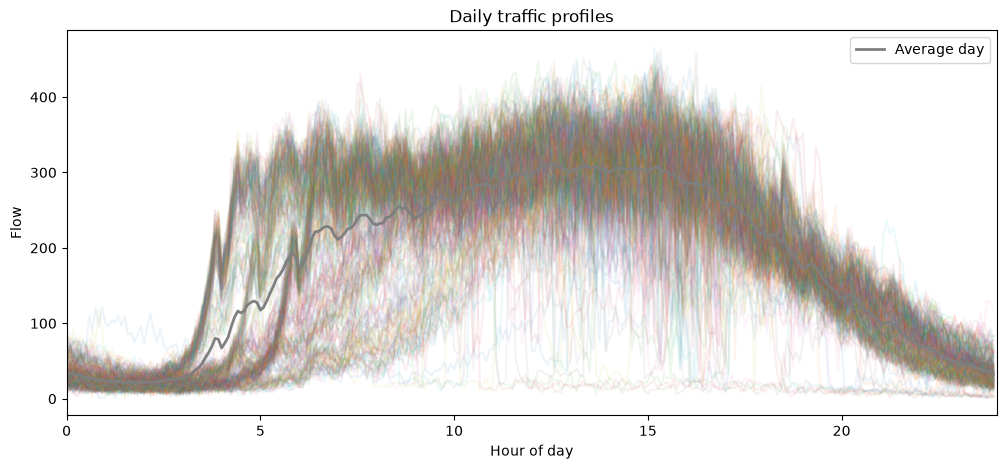

In [8]:
# Time axis in hours
x_axis_hours = np.arange(nintvals) * 5 / 60

plt.figure(figsize=(12, 5))

for day_profile in X_days:
    plt.plot(x_axis_hours, day_profile, alpha=0.08)

plt.plot(
    x_axis_hours,
    np.mean(X_days, axis=0),
    linewidth=2,
    label="Average day"
)

plt.xlabel("Hour of day")
plt.ylabel("Flow")
plt.title("Daily traffic profiles")
plt.xlim(0, 24)
plt.legend()
plt.show()

## 5. Create a reusable clustering function

Test many combinations of:
- method
- number of clusters
- method-specific parameters

in one go.

In [9]:
def make_clustering(method, n_clusters=None, eps=None, min_samples=None, random_state=0):
    if method == "KMeans":
        model = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init="auto"
        )
        labels = model.fit_predict(X_days)

    elif method == "Agglomerative":
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric="euclidean",
            linkage="ward"
        )
        labels = model.fit_predict(X_days)

    elif method == "DBSCAN":
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )
        labels = model.fit_predict(X_days)

    elif method == "GMM":
        model = GaussianMixture(
            n_components=n_clusters,
            random_state=random_state,
            n_init=5
        )
        labels = model.fit_predict(X_days)

    else:
        raise ValueError("Unknown clustering method.")

    return model, labels

## 6. Internal evaluation

Use three metrics from the exercise:

### Silhouette score
Higher is better.

### Calinski–Harabasz
Higher is better.

### Davies–Bouldin
Lower is better.

In [10]:
def calculate_internal_metrics(X, labels):
    
    unique_labels = np.unique(labels)
    cluster_labels = unique_labels[unique_labels != -1]

    if len(cluster_labels) < 2:
        return {
            "Silhouette": np.nan,
            "Calinski_Harabasz": np.nan,
            "Davies_Bouldin": np.nan,
            "n_clusters": len(cluster_labels),
            "noise_points": np.sum(labels == -1)
        }

    if -1 in unique_labels:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels

    if len(np.unique(labels_eval)) < 2:
        return {
            "Silhouette": np.nan,
            "Calinski_Harabasz": np.nan,
            "Davies_Bouldin": np.nan,
            "n_clusters": len(np.unique(labels_eval)),
            "noise_points": np.sum(labels == -1)
        }

    return {
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval, labels_eval),
        "n_clusters": len(np.unique(labels_eval)),
        "noise_points": np.sum(labels == -1)
    }

## 7. Test K-means with different numbers of clusters

In [114]:
kmeans_results = []

for k in range(2, 13):
    model, labels = make_clustering(
        method="KMeans",
        n_clusters=k,
        random_state=0
    )

    metrics = calculate_internal_metrics(X_days, labels)

    kmeans_results.append({
        "Method": "KMeans",
        "Parameter": f"k={k}",
        "k": k,
        **metrics
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

# results: higher number of cluster does not mean better results

,Method,Parameter,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,n_clusters,noise_points
0,KMeans,k=2,2,0.307621,174.104884,1.267725,2,0
1,KMeans,k=3,3,0.269241,159.134213,1.358789,3,0
2,KMeans,k=4,4,0.229860,122.801617,1.789675,4,0
3,KMeans,k=5,5,0.229698,114.694738,1.515830,5,0
4,KMeans,k=6,6,0.239601,115.185215,1.454940,6,0
5,KMeans,k=7,7,0.241332,103.050630,1.481357,7,0
6,KMeans,k=8,8,0.224635,94.887785,1.575806,8,0
7,KMeans,k=9,9,0.216715,86.615548,1.676599,9,0
8,KMeans,k=10,10,0.188830,81.054500,1.743424,10,0
9,KMeans,k=11,11,0.178876,77.748236,1.724123,11,0


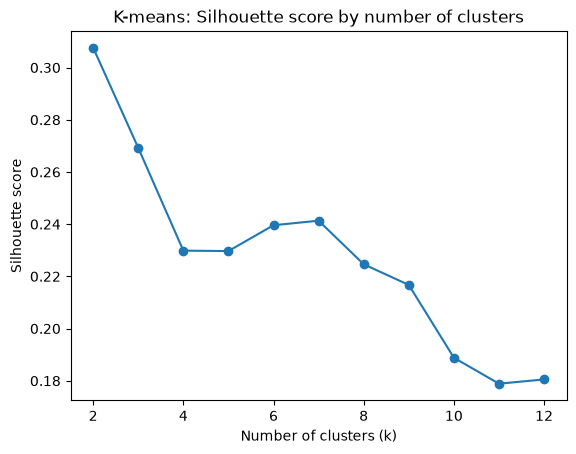

In [12]:
fig, ax = plt.subplots()

ax.plot(
    kmeans_results_df["k"],
    kmeans_results_df["Silhouette"],
    marker="o"
)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("K-means: Silhouette score by number of clusters")
plt.show()

## 8. Test Agglomerative clustering

In [13]:
agglomerative_results = []

for k in range(2, 13):
    model, labels = make_clustering(
        method="Agglomerative",
        n_clusters=k
    )

    metrics = calculate_internal_metrics(X_days, labels)

    agglomerative_results.append({
        "Method": "Agglomerative",
        "Parameter": f"k={k}",
        "k": k,
        **metrics
    })

agglomerative_results_df = pd.DataFrame(agglomerative_results)

agglomerative_results_df

# results: silhoutte is decreasing by the increase of k, calinksi opposie, and davies is random

,Method,Parameter,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,n_clusters,noise_points
0,Agglomerative,k=2,2,0.290945,159.821505,1.279138,2,0
1,Agglomerative,k=3,3,0.268112,148.607605,1.313811,3,0
2,Agglomerative,k=4,4,0.257637,127.187152,1.460274,4,0
3,Agglomerative,k=5,5,0.263778,118.054696,1.231404,5,0
4,Agglomerative,k=6,6,0.250363,108.679506,1.460171,6,0
5,Agglomerative,k=7,7,0.243157,100.749684,1.513606,7,0
6,Agglomerative,k=8,8,0.239635,91.736572,1.440534,8,0
7,Agglomerative,k=9,9,0.233039,84.412420,1.390687,9,0
8,Agglomerative,k=10,10,0.215062,78.955196,1.415068,10,0
9,Agglomerative,k=11,11,0.192062,74.390703,1.540013,11,0


## 9. Test GMM

In [115]:
gmm_results = []

for k in range(2, 13):
    model, labels = make_clustering(
        method="GMM",
        n_clusters=k,
        random_state=0
    )

    metrics = calculate_internal_metrics(X_days, labels)

    gmm_results.append({
        "Method": "GMM",
        "Parameter": f"k={k}",
        "k": k,
        **metrics
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df

# results: same pattern as agglomeration

,Method,Parameter,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,n_clusters,noise_points
0,GMM,k=2,2,0.307557,174.101733,1.269963,2,0
1,GMM,k=3,3,0.269241,159.134213,1.358789,3,0
2,GMM,k=4,4,0.229860,122.801617,1.789675,4,0
3,GMM,k=5,5,0.235292,114.489734,1.683207,5,0
4,GMM,k=6,6,0.235099,114.728769,1.488245,6,0
5,GMM,k=7,7,0.218641,102.869954,1.565549,7,0
6,GMM,k=8,8,0.213025,93.285962,1.780040,8,0
7,GMM,k=9,9,0.216715,86.615548,1.676599,9,0
8,GMM,k=10,10,0.188830,81.054500,1.743424,10,0
9,GMM,k=11,11,0.149831,74.858249,1.920095,11,0


## 10. Test DBSCAN

In [15]:
dbscan_results = []

# These are deliberately a small starting grid.
# If all settings produce 0/1 clusters or too many tiny clusters,
# expand or adjust eps.
eps_values = [500, 1000, 1500, 2000, 3000]
min_samples_values = [2, 3, 5]

for eps in eps_values:
    for min_samples in min_samples_values:
        model, labels = make_clustering(
            method="DBSCAN",
            eps=eps,
            min_samples=min_samples
        )

        metrics = calculate_internal_metrics(X_days, labels)

        dbscan_results.append({
            "Method": "DBSCAN",
            "Parameter": f"eps={eps}, min_samples={min_samples}",
            "eps": eps,
            "min_samples": min_samples,
            **metrics
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df

# results: boh

,Method,Parameter,eps,min_samples,Silhouette,Calinski_Harabasz,Davies_Bouldin,n_clusters,noise_points
0,DBSCAN,"eps=500, min_samples=2",500,2,0.327729,109.922957,1.052498,6,167
1,DBSCAN,"eps=500, min_samples=3",500,3,0.327729,109.922957,1.052498,6,167
2,DBSCAN,"eps=500, min_samples=5",500,5,0.355637,124.973015,1.039452,5,182
3,DBSCAN,"eps=1000, min_samples=2",1000,2,0.542666,14.936362,0.516205,2,9
4,DBSCAN,"eps=1000, min_samples=3",1000,3,NaN,NaN,NaN,1,11
5,DBSCAN,"eps=1000, min_samples=5",1000,5,NaN,NaN,NaN,1,11
6,DBSCAN,"eps=1500, min_samples=2",1500,2,0.533071,21.008339,0.585616,2,1
7,DBSCAN,"eps=1500, min_samples=3",1500,3,0.533071,21.008339,0.585616,2,1
8,DBSCAN,"eps=1500, min_samples=5",1500,5,NaN,NaN,NaN,1,4
9,DBSCAN,"eps=2000, min_samples=2",2000,2,NaN,NaN,NaN,1,0


## 11. Put all internal results together

Compare all three and reminder:

- **Silhouette:** higher = better
- **Calinski–Harabasz:** higher = better
- **Davies–Bouldin:** lower = better

In [116]:
all_internal_results = pd.concat(
    [
        kmeans_results_df,
        agglomerative_results_df,
        gmm_results_df,
        dbscan_results_df
    ],
    ignore_index=True
)

all_internal_results.sort_values(
    "Silhouette", # replace: Silhouette, Calinski_Harabasz, and Calinski_Harabasz
    ascending=False
).head(5)

# Calinski_Harabasz results differ from the other two

,Method,Parameter,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,n_clusters,noise_points,eps,min_samples
36,DBSCAN,"eps=1000, min_samples=2",NaN,0.542666,14.936362,0.516205,2,9,1000.0,2.0
40,DBSCAN,"eps=1500, min_samples=3",NaN,0.533071,21.008339,0.585616,2,1,1500.0,3.0
39,DBSCAN,"eps=1500, min_samples=2",NaN,0.533071,21.008339,0.585616,2,1,1500.0,2.0
35,DBSCAN,"eps=500, min_samples=5",NaN,0.355637,124.973015,1.039452,5,182,500.0,5.0
33,DBSCAN,"eps=500, min_samples=2",NaN,0.327729,109.922957,1.052498,6,167,500.0,2.0


## 12. External evaluation: why do we do this?

In [76]:
# Prepare the evaluation dataset in the same day × time format

data_eval_df = data_eval_df.sort_values(["Date", "Interval_5"])

days_eval = np.unique(data_eval_df["Date"].values)
ndays_eval = len(days_eval)

day_eval_subsets_df = data_eval_df.groupby("Date")

vectorized_day_dataset_eval = np.full((ndays_eval, nintvals), np.nan)

for i, day in enumerate(days_eval):
    df_t = day_eval_subsets_df.get_group(day)

    for _, row in df_t.iterrows():
        vectorized_day_dataset_eval[i, int(row["Interval_5"])] = row["flow"]

nans_per_day_eval = np.sum(np.isnan(vectorized_day_dataset_eval), axis=1)

complete_eval_indices = np.where(nans_per_day_eval == 0)[0]

X_eval = vectorized_day_dataset_eval[complete_eval_indices, :]
days_eval_complete = days_eval[complete_eval_indices]

print("Evaluation days:", ndays_eval)
print("Complete evaluation days:", len(days_eval_complete))
print("Evaluation matrix shape:", X_eval.shape)

Evaluation days: 80
Complete evaluation days: 69
Evaluation matrix shape: (69, 288)


## 13. Build centroids

In [77]:
def calculate_centroids(X, labels):
    centroids = {}

    for cluster_id in np.unique(labels):
        if cluster_id == -1:
            continue

        cluster_days = X[labels == cluster_id]

        if len(cluster_days) > 0:
            centroids[int(cluster_id)] = np.mean(cluster_days, axis=0)

    return centroids

## 14. External prediction function

Wee change from class: `n_past_intervals=5` means we use the previous 25 minutes to identify the most similar day-type.

The prediction itself is only the **next 5-minute value**, so the future value is not used when selecting the centroid.

In [78]:
def evaluate_centroid_prediction(
    X_train,
    labels,
    X_eval,
    n_past_intervals=5
):
    centroids_dict = calculate_centroids(X_train, labels)

    if len(centroids_dict) < 1:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "Predictions": 0
        }

    centroids = list(centroids_dict.values())

    errors = []
    percentage_errors = []

    for day in X_eval:
        for j in range(n_past_intervals, nintvals - 1):

            # Recent observed history: j-4 ... j
            recent_history = day[
                j - n_past_intervals + 1 : j + 1
            ]

            # Find the centroid whose corresponding recent history
            # is closest to the observed recent history.
            distances = []

            for centroid in centroids:
                centroid_history = centroid[
                    j - n_past_intervals + 1 : j + 1
                ]

                distance = np.linalg.norm(
                    centroid_history - recent_history
                )

                distances.append(distance)

            closest_centroid_index = np.argmin(distances)

            # Predict the NEXT interval
            predicted_value = centroids[
                closest_centroid_index
            ][j + 1]

            actual_value = day[j + 1]

            error = abs(predicted_value - actual_value)
            errors.append(error)

            # Avoid division by zero for MAPE
            if actual_value != 0:
                percentage_errors.append(
                    error / abs(actual_value)
                )

    return {
        "MAE": np.mean(errors),
        "RMSE": np.sqrt(np.mean(np.square(errors))),
        "MAPE": np.mean(percentage_errors),
        "Predictions": len(errors)
    }

## 15. Run external evaluation on the candidate clusterings

In [79]:

# add the candidates from the internal val from both results 
candidate_models = [
    # K-means
    ("KMeans", {"n_clusters": 2}),
    ("KMeans", {"n_clusters": 3}),

    # GMM
    ("GMM", {"n_clusters": 2}),
    ("GMM", {"n_clusters": 3}),

    # Agglomerative
    ("Agglomerative", {"n_clusters": 2}),

    # DBSCAN
    ("DBSCAN", {"eps": 1000, "min_samples": 2}),
    ("DBSCAN", {"eps": 1500, "min_samples": 2}),
    ("DBSCAN", {"eps": 1500, "min_samples": 3}),
]

external_results = []

for method, params in candidate_models:
    model, labels = make_clustering(
        method=method,
        random_state=0,
        **params
    )

    internal = calculate_internal_metrics(X_days, labels)

    external = evaluate_centroid_prediction(
        X_train=X_days,
        labels=labels,
        X_eval=X_eval,
        n_past_intervals=5
    )

    external_results.append({
        "Method": method,
        **params,
        "Silhouette": internal["Silhouette"],
        "Calinski_Harabasz": internal["Calinski_Harabasz"],
        "Davies_Bouldin": internal["Davies_Bouldin"],
        "MAE": external["MAE"],
        "RMSE": external["RMSE"],
        "MAPE": external["MAPE"],
        "Predictions": external["Predictions"]
    })

external_results_df = pd.DataFrame(external_results)

external_results_df.sort_values("MAE")

,Method,n_clusters,Silhouette,Calinski_Harabasz,Davies_Bouldin,MAE,RMSE,MAPE,Predictions,eps,min_samples
1,KMeans,3.0,0.269241,159.134213,1.358789,25.253948,39.651109,0.321423,19458,NaN,NaN
3,GMM,3.0,0.269241,159.134213,1.358789,25.253948,39.651109,0.321423,19458,NaN,NaN
0,KMeans,2.0,0.307621,174.104884,1.267725,27.867369,43.469626,0.363247,19458,NaN,NaN
2,GMM,2.0,0.307557,174.101733,1.269963,27.882477,43.468203,0.363311,19458,NaN,NaN
4,Agglomerative,2.0,0.290945,159.821505,1.279138,28.072168,43.856173,0.371372,19458,NaN,NaN
6,DBSCAN,NaN,0.533071,21.008339,0.585616,37.943740,54.480278,0.366665,19458,1500.0,2.0
7,DBSCAN,NaN,0.533071,21.008339,0.585616,37.943740,54.480278,0.366665,19458,1500.0,3.0
5,DBSCAN,NaN,0.542666,14.936362,0.516205,39.110302,56.272640,0.391336,19458,1000.0,2.0


## 16. Visualise the candidate centroids

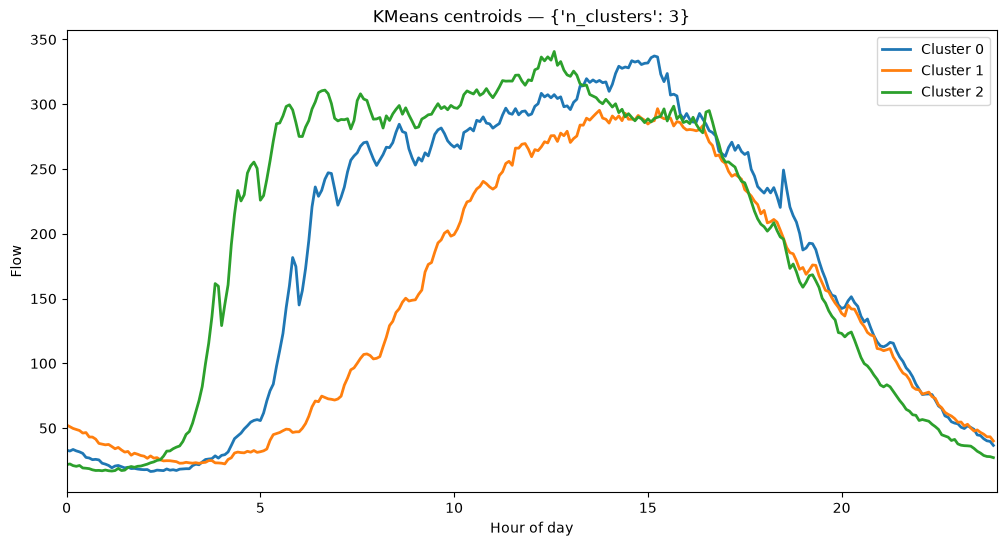

In [88]:
# kmeans with 3 clusters:

def plot_centroids(X, labels, title):
    centroids = calculate_centroids(X, labels)

    plt.figure(figsize=(12, 6))

    for cluster_id, centroid in centroids.items():
        plt.plot(
            x_axis_hours,
            centroid,
            linewidth=2,
            label=f"Cluster {cluster_id}"
        )

    plt.xlabel("Hour of day")
    plt.ylabel("Flow")
    plt.title(title)
    plt.xlim(0, 24)
    plt.legend()
    plt.show()


# Change these parameters to the clustering you want to inspect.
chosen_method = "KMeans"
chosen_params = {"n_clusters": 3}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)


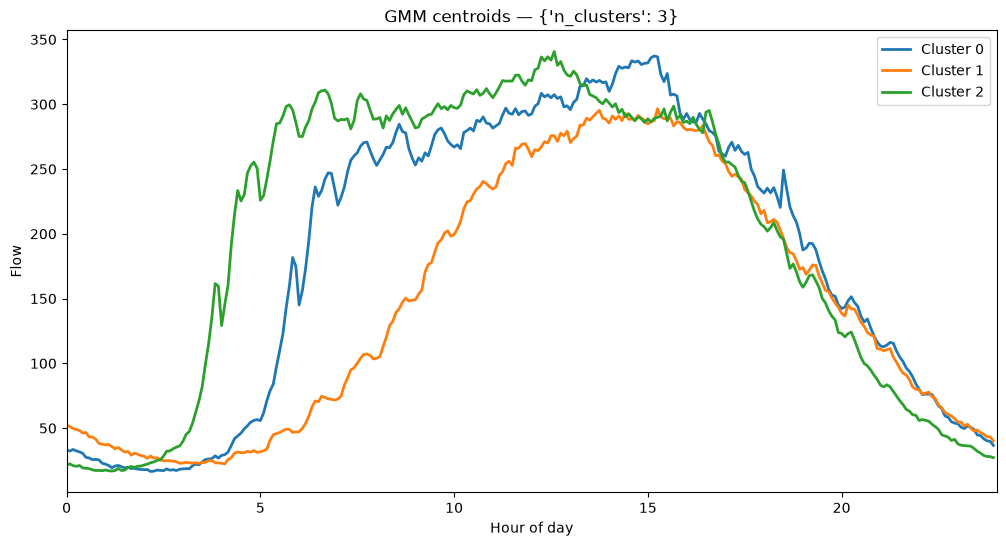

In [107]:
# GMM with 3 clusters:
chosen_method = "GMM"
chosen_params = {"n_clusters": 3}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)

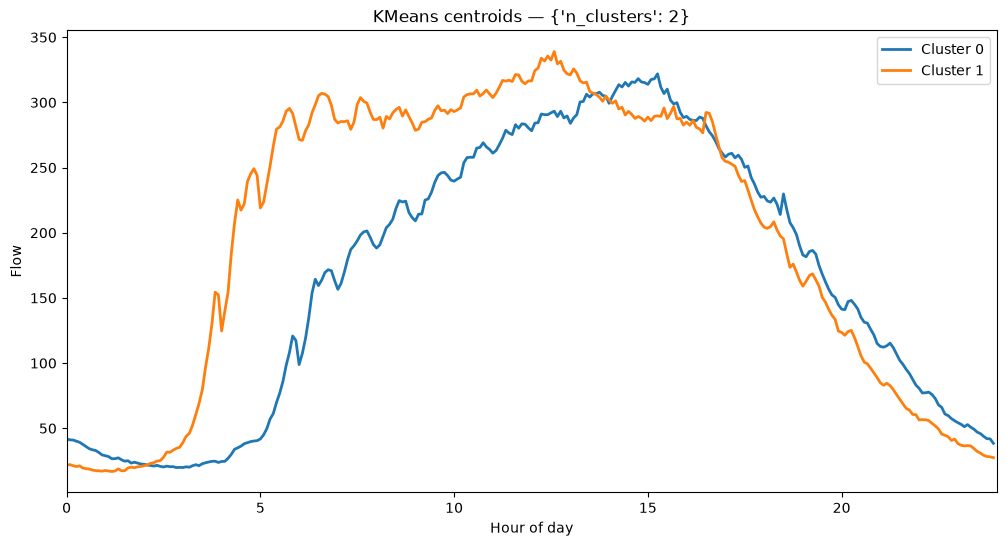

In [94]:
# kmeans with 2 clusters:
chosen_method = "KMeans"
chosen_params = {"n_clusters": 2}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)

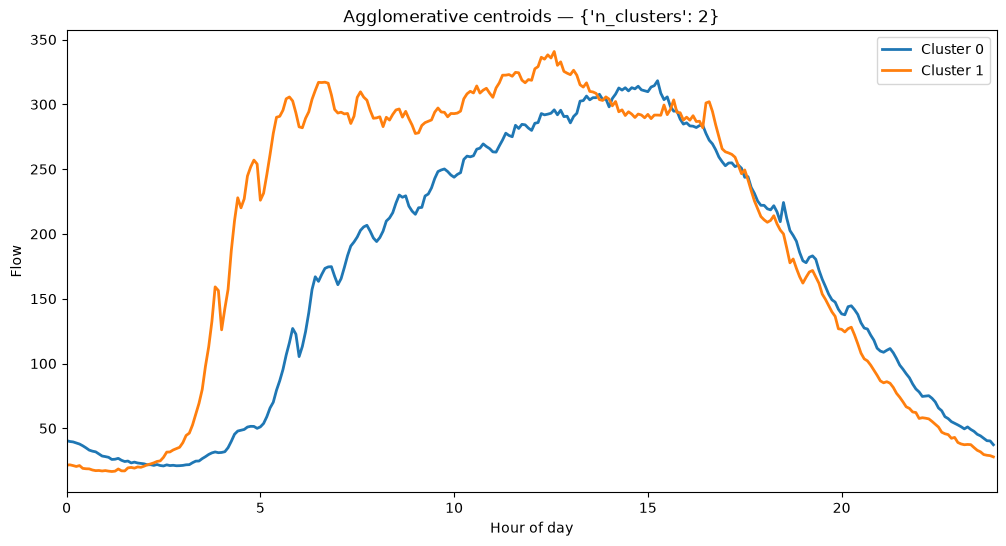

In [97]:
# agglo with 2 clusters:
chosen_method = "Agglomerative"
chosen_params = {"n_clusters": 2}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)

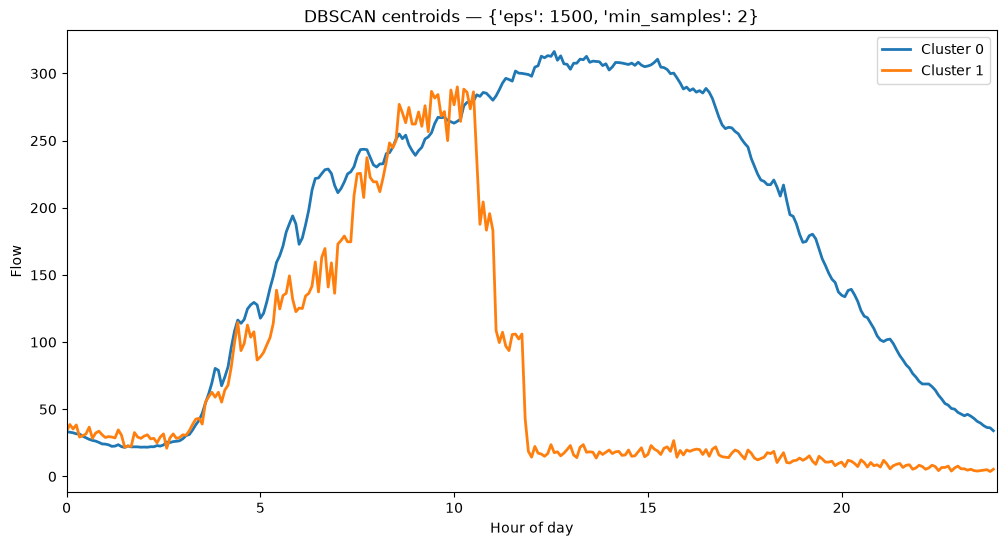

In [108]:
# DBSCAN with eps 1500 and 2 min sam:
chosen_method = "DBSCAN"
chosen_params = {
    "eps": 1500,
    "min_samples": 2
}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)

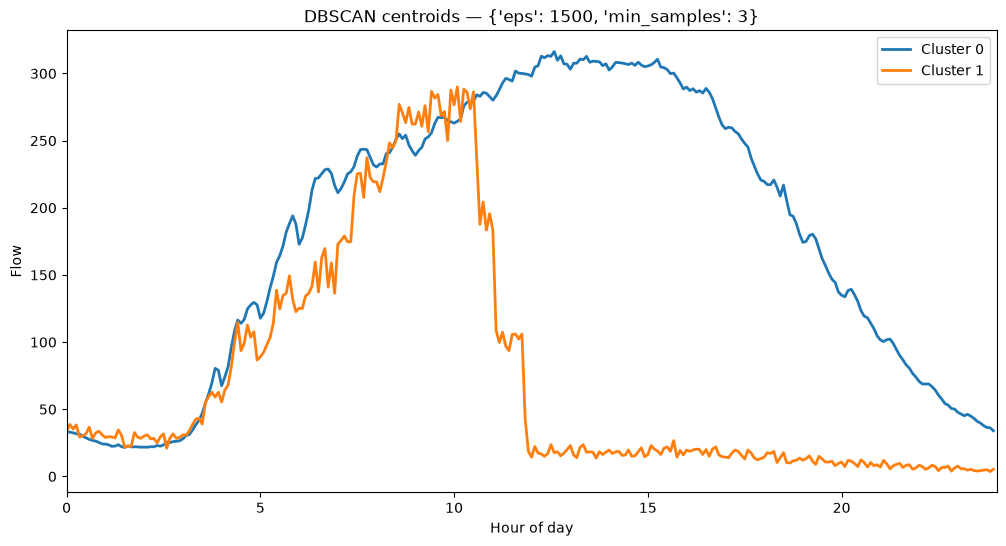

In [117]:
# DBSCAN with eps 1500 and 3 min sam:
chosen_method = "DBSCAN"
chosen_params = {
    "eps": 1500,
    "min_samples": 3
}

chosen_model, chosen_labels = make_clustering(
    chosen_method,
    random_state=0,
    **chosen_params
)

plot_centroids(
    X_days,
    chosen_labels,
    f"{chosen_method} centroids — {chosen_params}"
)

## 17. See which dates belong to each cluster

In [109]:
def show_cluster_dates(days, labels):
    result = pd.DataFrame({
        "Date": days,
        "Cluster": labels
    })

    result["Date"] = pd.to_datetime(result["Date"].astype(str))
    result["Day_of_week"] = result["Date"].dt.day_name()

    return result.sort_values(["Cluster", "Date"])


cluster_dates = show_cluster_dates(days_complete, chosen_labels)



In [110]:
# Distribution of days of the week within each cluster
weekday_distribution = pd.crosstab(
    cluster_dates["Cluster"],
    cluster_dates["Day_of_week"],
    normalize="index"
) * 100

weekday_distribution.round(1)

Day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Cluster,,,,,,,
-1,100.0,0.0,0.0,0.0,0.0,0.0,0.0
0,14.7,13.8,15.3,14.4,14.4,13.8,13.5
1,0.0,0.0,33.3,33.3,33.3,0.0,0.0


## 18. Check cluster sizes

In [111]:
cluster_sizes = pd.Series(chosen_labels).value_counts().sort_index()

cluster_sizes_df = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Number_of_days": cluster_sizes.values,
    "Share_of_complete_days_%": (
        cluster_sizes.values / len(chosen_labels) * 100
    )
})

cluster_sizes_df

,Cluster,Number_of_days,Share_of_complete_days_%
0,-1,1,0.296736
1,0,333,98.813056
2,1,3,0.890208


In [112]:
# check dates maeaning:
cluster_4_dates = cluster_dates[cluster_dates["Cluster"] == 1]

cluster_4_dates

,Date,Cluster,Day_of_week
175,2021-07-04,1,Sunday
202,2021-08-05,1,Thursday
253,2021-10-02,1,Saturday
